In [1]:
%reload_ext autoreload
%autoreload 2

# Imports

In [ ]:
from kret_notebook import *  # NOTE import first

# from kret_lgbm._core.lgbm_nb_imports import *
# from kret_lightning._core.lightning_nb_imports import *
from kret_matplotlib._core.mpl_nb_imports import *
from kret_np_pd._core.np_pd_nb_imports import *

# from kret_optuna._core.optuna_nb_imports import *
from kret_polars._core.polars_nb_imports import *
from kret_rosetta._core.rosetta_nb_imports import *

# from kret_sklearn._core.sklearn_nb_imports import *
# from kret_torch_utils._core.torch_nb_imports import *
# from kret_tqdm._core.tqdm_nb_imports import *
from kret_type_hints._core.types_nb_imports import *
from kret_utils._core.utils_nb_imports import *

# from kret_wandb._core.wandb_nb_imports import *  # NOTE this is slow to import

Loaded environment variables from /Users/Akseldkw/coding/Columbia/NBA-Timeout-Impact/.env
[kret_lgbm._core.lgbm_nb_imports] Imported kret_lgbm._core.lgbm_nb_imports in 2.2611 seconds
[kret_lightning._core.lightning_nb_imports] Imported kret_lightning._core.lightning_nb_imports in 4.5062 seconds
[kret_matplotlib._core.mpl_nb_imports] Imported kret_matplotlib._core.mpl_nb_imports in 0.4222 seconds
[kret_np_pd._core.np_pd_nb_imports] Imported kret_np_pd._core.np_pd_nb_imports in 0.0006 seconds
[kret_optuna._core.optuna_nb_imports] Imported kret_optuna._core.optuna_nb_imports in 0.0010 seconds
[kret_polars._core.polars_nb_imports] Imported kret_polars._core.polars_nb_imports in 0.0000 seconds
[kret_rosetta._core.rosetta_nb_imports] Imported kret_rosetta._core.rosetta_nb_imports in 0.0000 seconds
[kret_sklearn._core.sklearn_nb_imports] Imported kret_sklearn._core.sklearn_nb_imports in 0.0895 seconds
[kret_torch_utils._core.torch_nb_imports] Imported kret_torch_utils._core.torch_nb_imports i

In [3]:
from nba_timeout_impact.nb_imports import *

# TV / mandatory timeout study

Two questions:

1. **Visual evidence** that mandatory timeouts in cdnnba (post-2017) already exist as ordinary `subType="full"` rows, clustering at the rulebook trigger marks.
2. **Reclassification** of each timeout row's role (slot_K_mandatory / slot_K_absorbed / discretionary / challenge), tested on the v3 labeled era (1998-2016) against ground-truth `Official` / `Official TV` subTypes.

# Load data

In [4]:
from nba_timeout_impact.datasets.memo_nbastatsv3 import NBAMemoDF
from nba_timeout_impact.datasets.memo_cdnnba_pl import CDNNBAMemoPL
from nba_timeout_impact.data_pipes.tv_timeout_injection import TVTimeoutValidation

memo_v3 = NBAMemoDF.load_all()  # nbastatsv3 + nbastats v2 (~1s)
memo_cdn = CDNNBAMemoPL.load_all()  # cdnnba post-2017 (~3s)

Validating cdnnba data (Polars)...
  Passed (4,168,786 rows, 74 cols, 1 warnings).
Validating boxscores data (Polars)...
  Passed (217,190 rows, 36 cols).
Validating player_advanced_stats data (Polars)...
  Passed (3,400 rows, 119 cols).
Validating player_season_stats data (Polars)...
  Passed (5,174 rows, 31 cols).
Validating rotations data (Polars)...
  Passed (1,905,583 rows, 16 cols, 1 warnings).
Validating stints data (Polars)...
  Passed (2,145,106 rows, 14 cols, 1 warnings).


# Part 1 — Density of cdnnba timeouts by clock bin

The cdnnba memo has a parameterized `sr_bin(width)` column. Plot the
density of `full` and `challenge` timeouts at 15s / 30s / 60s resolutions
to see where they cluster relative to the rulebook trigger marks (7:00
and 3:00 = sr=420 and sr=180).

Calculating bin_sr(15,)
Calculating bin_sr(30,)
Calculating bin_sr(60,)


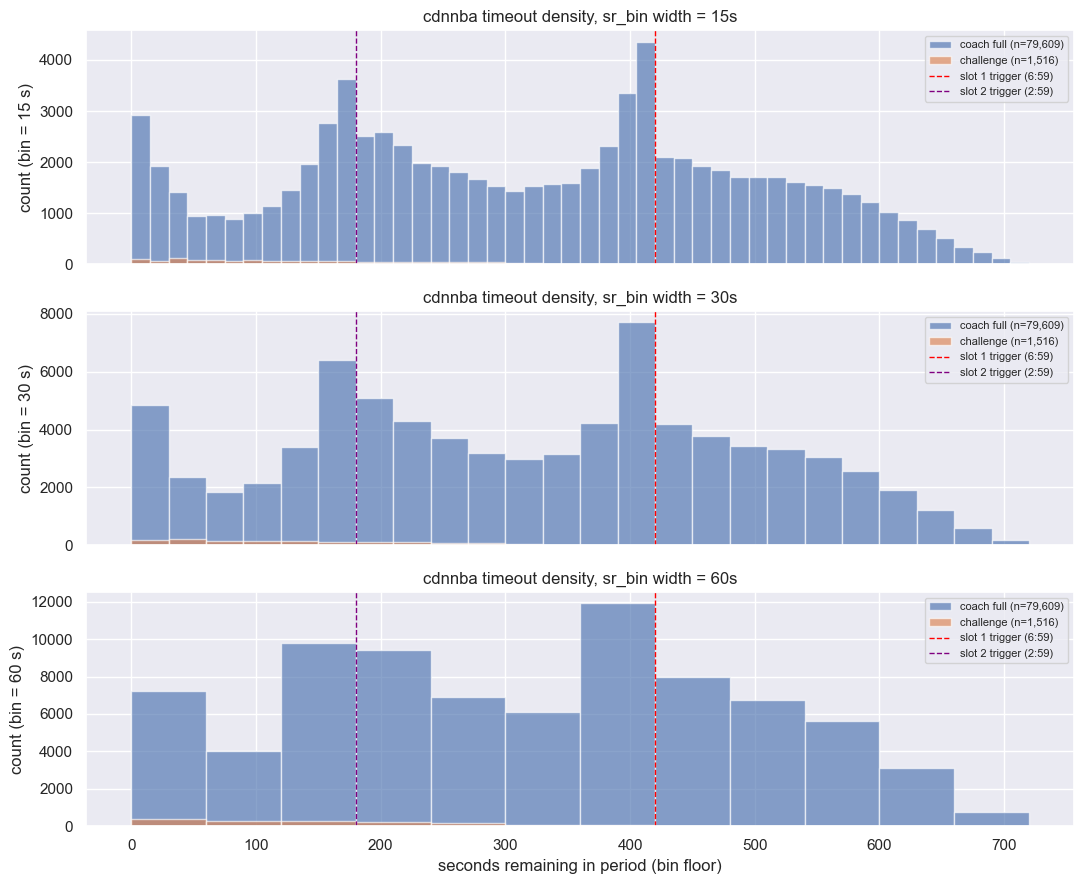

In [ ]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

df = pl.DataFrame._from_pydf(memo_cdn.cdnnba._df)
df = df.filter((pl.col("actionType") == "timeout") & pl.col("period").is_in([1, 2, 3, 4]))

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
for ax, width in zip(axes, [15, 30, 60]):
    binned = df.with_columns(memo_cdn.bin_sr(width).gather(df["orderNumber"] - df["orderNumber"]))  # dummy alignment
    # simpler: just compute bins directly here
    bins = (df["seconds_remaining"] // width * width).cast(pl.Int32)
    df2 = df.with_columns(bins.alias("sr_bin"))
    for sub, color, label in [("full", "C0", "coach full"), ("challenge", "C1", "challenge")]:
        vals = df2.filter(pl.col("subType") == sub)["sr_bin"].to_numpy()
        if len(vals) == 0:
            continue
        ax.hist(
            vals, bins=np.arange(0, 720 + width, width), alpha=0.65, label=f"{label} (n={len(vals):,})", color=color
        )
    ax.axvline(420, color="red", linestyle="--", linewidth=1, label="slot 1 trigger (6:59)")
    ax.axvline(180, color="purple", linestyle="--", linewidth=1, label="slot 2 trigger (2:59)")
    ax.set_ylabel(f"count (bin = {width} s)")
    ax.set_title(f"cdnnba timeout density, sr_bin width = {width}s")
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("seconds remaining in period (bin floor)")
plt.tight_layout()
plt.show()

# Part 3 - cdnnba classification 

Examine the cdnnba data and predictions


## Plots

In [ ]:
cdn_pl = TVTimeoutValidation._prep_cdnnba(memo_cdn, seasons=(2020, 2025))
classified = TVTimeoutValidation.classify_timeouts(cdn_pl, source="cdnnba", seasons=(2020, 2025))

In [8]:
# Validation
r = TVTimeoutValidation.validate_against_cdnnba(memo_cdn, seasons=(2020, 2025))
print(r.summary())  # F1=1.000 (predicting from the same signal we score on)

# Confusion matrix
TVTimeoutValidation.confusion_matrix_cdnnba(memo_cdn, seasons=(2020, 2025))

cdnnba reclassification: n_gt=56,895 n_pred=56,895 TP=56,895 FP=0 FN=0 | P=1.000 R=1.000 F1=1.000


predicted_role,challenge,discretionary,slot_1_mandatory,slot_2_mandatory,TOTAL
gt,,,,,
mandatory,0,0,48530,8365,56895
not_mandatory,1555,23747,0,0,25302
TOTAL,1555,23747,48530,8365,82197


In [24]:
figs = TimeoutInjectionPlots.diagnose_cdnnba(classified, full_pbp_pl=memo_cdn)

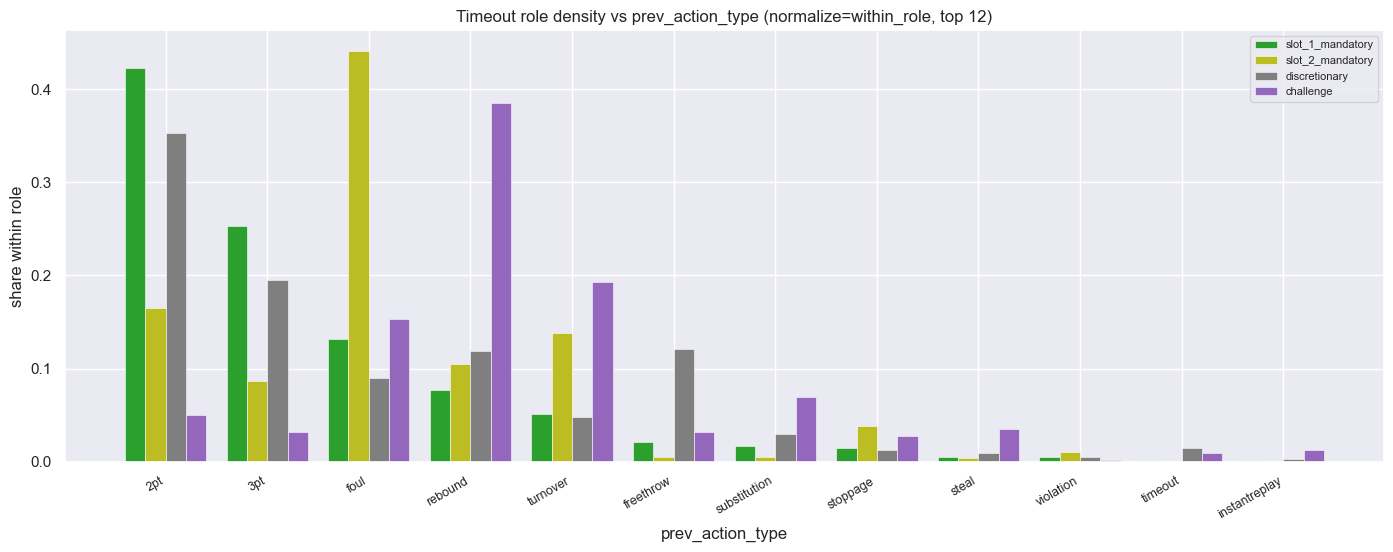

In [25]:
figs["role_vs_prev_action_type"]

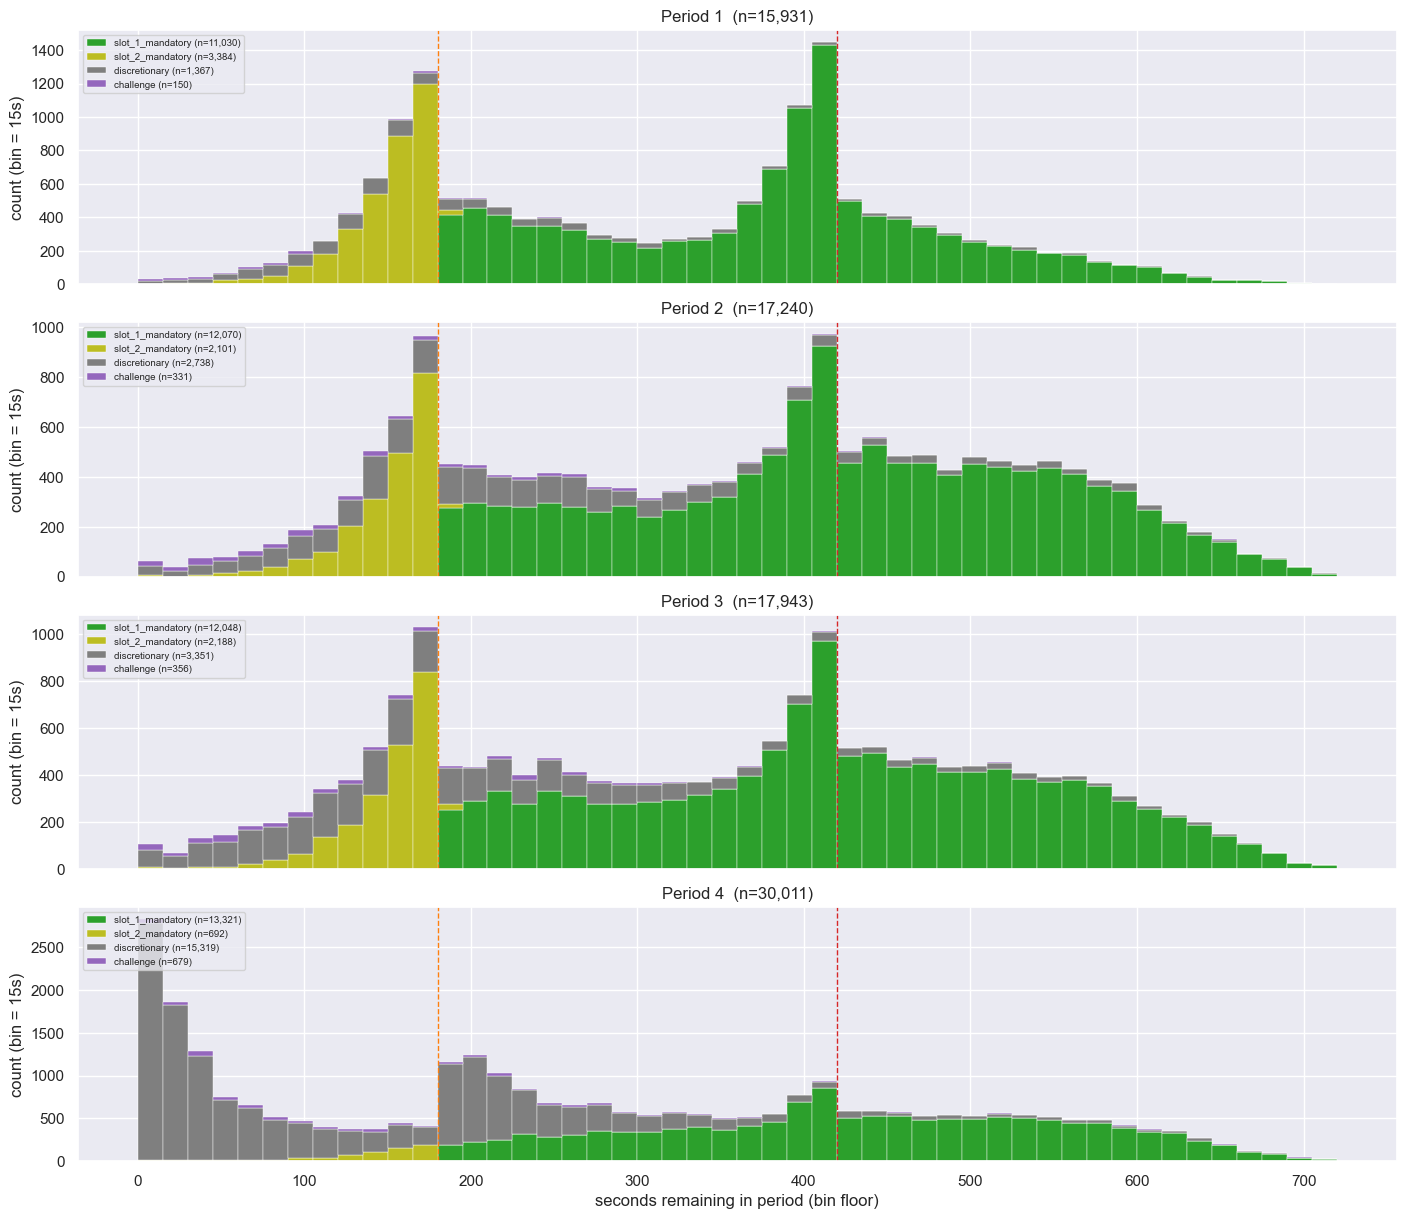

In [26]:
figs["role_vs_sr"]

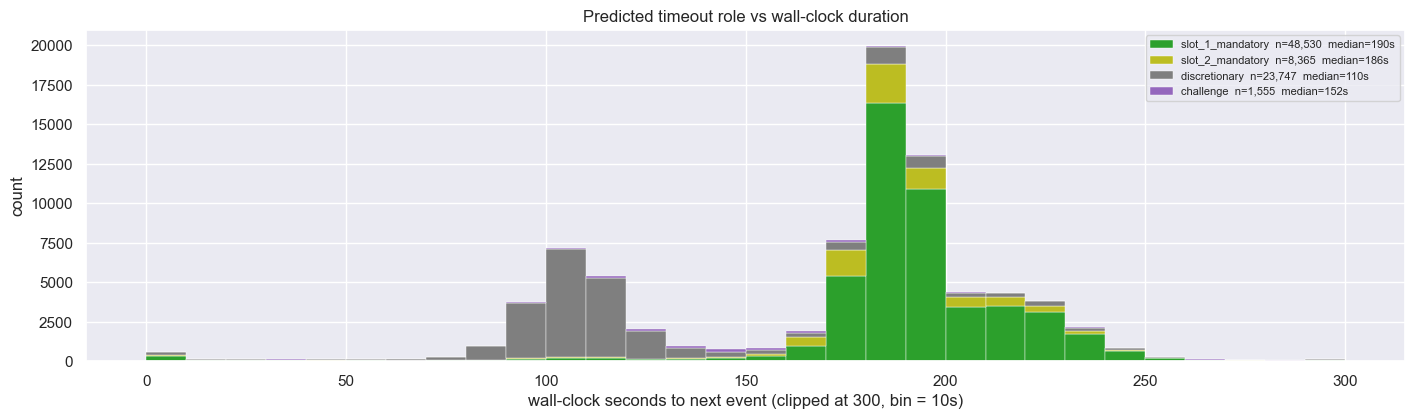

In [27]:
figs["role_vs_duration"]

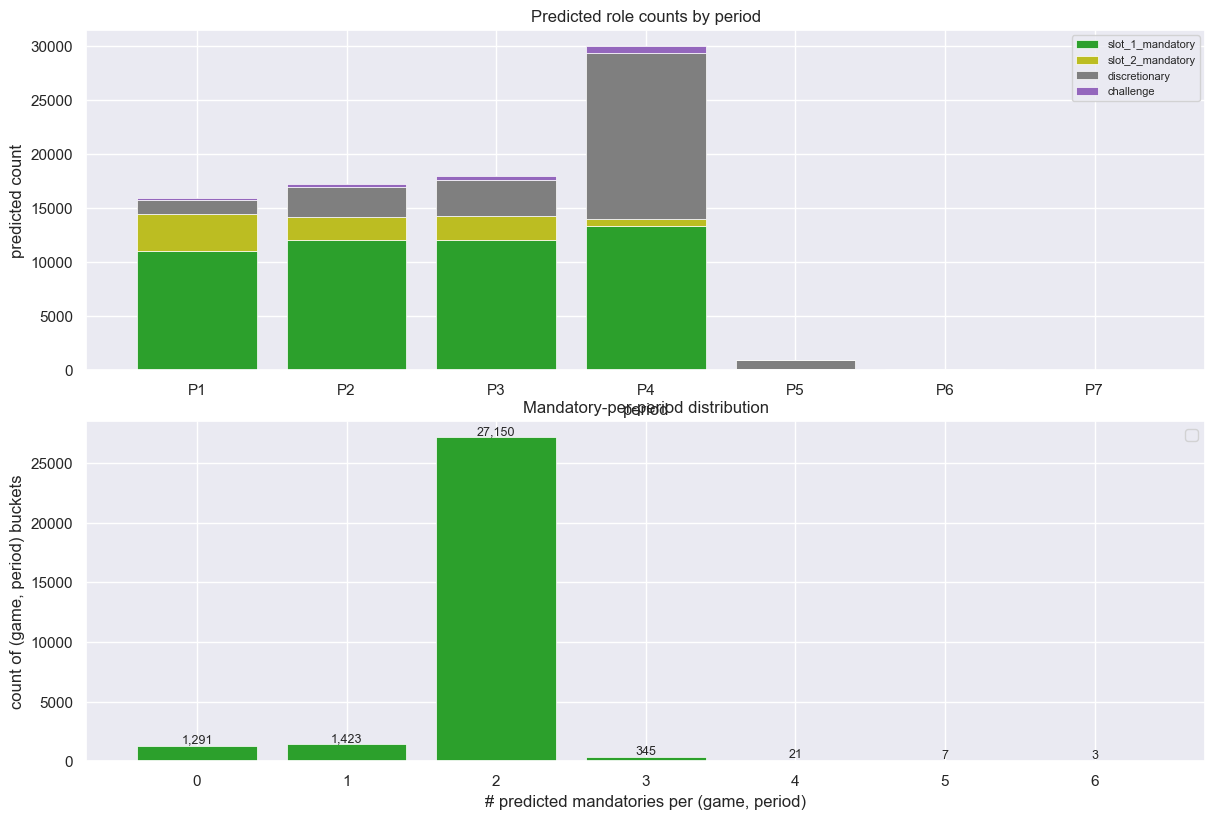

In [28]:
figs["role_counts_per_period"]

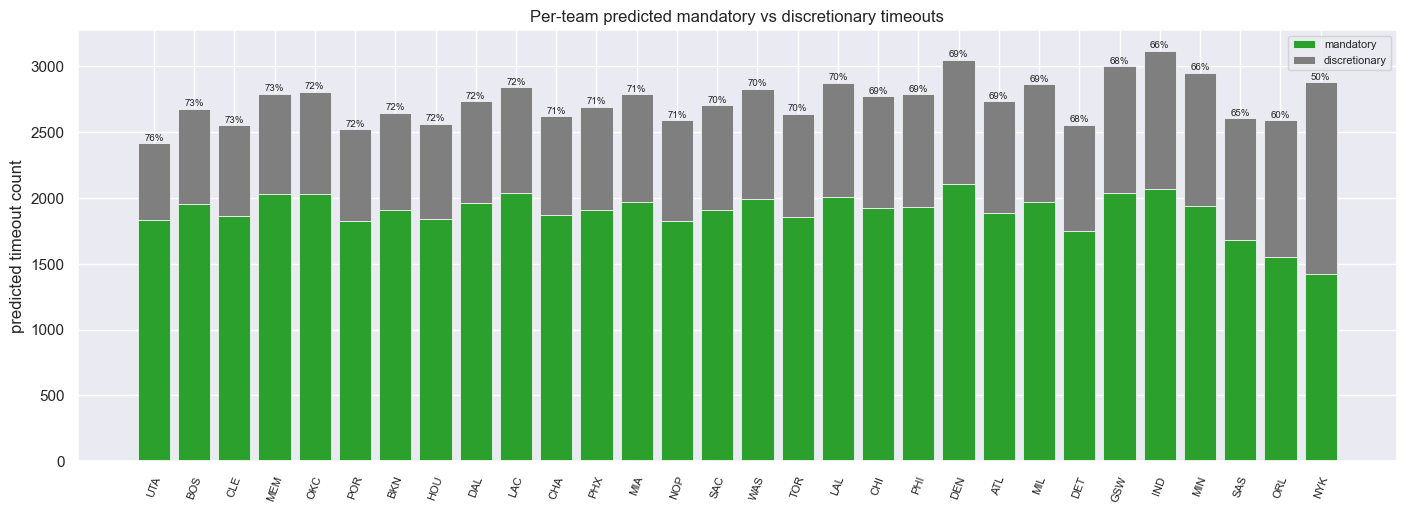

In [29]:
figs["team_mandatory_share"]

# Sandbox

In [9]:
index = [1300906, 543597]
f_index = np.zeros(len(memo_cdn.cdnnba), dtype=bool)
f_index[index] = True

In [18]:
# help(UKS_NP_PD.get_nearby_rows) / UKS_NP_PD.get_nearby_rows?

In [20]:
f_nearby = UKS_NP_PD.get_nearby_rows(
    memo_cdn.cdnnba, f_index, hard_match=["gameId", "period"], soft_match={"seconds_elapsed": (60, "backward")}
)
f_nearby.sum()

np.int64(39)

In [17]:
# sorted(memo_cdn.cdnnba.columns)

In [ ]:
UKS_NP_PD.dtt(
    memo_cdn.cdnnba,
    # filter=memo_cdn.f_timeout,
    # filter=f_index,
    filter=f_nearby,
    n=-1,
)

,game_date,gameId,orderNumber,actionType,subType,description,scoreHome,scoreAway,pointsTotal,possession,period,game_seconds_elapsed,seconds_remaining,seconds_elapsed,IsPlayoff,periodType,qualifiers,edited,isFieldGoal,side,personIdsFilter,teamTricode,descriptor,jumpBallRecoveredName,jumpBallWonPlayerName,jumpBallWonPersonId,jumpBallLostPlayerName,jumpBallLostPersonId,officialId,turnoverTotal,foulPersonalTotal,foulTechnicalTotal,foulDrawnPlayerName,foulDrawnPersonId,shotResult,assistPlayerNameInitial,assistPersonId,assistTotal,shotActionNumber,reboundTotal,reboundDefensiveTotal,reboundOffensiveTotal,blockPlayerName,blockPersonId,jumpBallRecoverdPersonId,stealPlayerName,stealPersonId,area,areaDetail,isTargetScoreLastPeriod,playerNameI,actionNumber,clock,timeActual,teamId,personId,playerName,xLegacy,yLegacy,x,y,shotDistance,season_type,season,shot_value,points_scored,score_margin,is_clutch,prev_action_type,x_court,y_court,possession_id,possession_points,possession_outcome
,datetime64[ms],int64,int64,category,category,str,int64,int64,float64,int64,int64,float64,float64,float64,bool,category,str,"datetime64[us, UTC]",int64,category,str,category,str,str,str,float64,str,float64,float64,float64,float64,float64,str,float64,category,str,float64,float64,float64,float64,float64,float64,str,float64,float64,str,float64,category,category,object,category,int64,str,"datetime64[us, UTC]",float64,int64,category,float64,float64,float64,float64,float64,str,int64,float64,int64,int64,bool,category,float64,float64,float64,float64,str
543585,2021-05-04,22000980,6080000,2pt,Jump Shot,D. Rose 6' driving floating Jump Shot (23 PTS),101,108,23.000,1610612752,4,2774.000,106.000,614.000,False,REGULAR,pointsinthepaint,2021-05-04 03:15:00+00:00,1,left,201565,NYK,driving floating,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Made,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,D. Rose,614,PT01M46.00S,2021-05-04 03:14:55.600000+00:00,1610612752.000,201565,Rose,-16.000,61.000,12.040,53.255,6.290,rg,2020,2.000,2,-7,False,3pt,-16.000,61.000,186.000,2.000,made_2pt
543586,2021-05-04,22000980,6090000,2pt,Jump Shot,MISS J. Morant 10' driving floating Shot,101,108,NaN,1610612763,4,2787.000,93.000,627.000,False,REGULAR,pointsinthepaint,2021-05-04 03:15:13+00:00,1,right,1629630,MEM,driving floating,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Missed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,J. Morant,615,PT01M33.00S,2021-05-04 03:15:10+00:00,1610612763.000,1629630,Morant,-50.000,96.000,84.182,40.020,10.840,rg,2020,2.000,0,-7,False,2pt,-50.000,96.000,187.000,0.000,miss
543587,2021-05-04,22000980,6100000,rebound,defensive,T. Gibson REBOUND (Off:5 Def:7),101,108,NaN,1610612752,4,2790.000,90.000,630.000,False,REGULAR,NaN,2021-05-04 03:15:13+00:00,0,NaN,201959,NYK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,615.000,12.000,7.000,5.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,T. Gibson,616,PT01M30.00S,2021-05-04 03:15:13+00:00,1610612752.000,201959,Gibson,NaN,NaN,NaN,NaN,NaN,rg,2020,NaN,0,-7,False,2pt,NaN,NaN,188.000,4.000,made_2pt_and1
543588,2021-05-04,22000980,6110000,foul,technical,TEAM foul technical,101,108,NaN,1610612752,4,2800.000,80.000,640.000,False,REGULAR,1freethrow,2021-05-04 03:15:50+00:00,0,NaN,203624,MEM,NaN,NaN,NaN,NaN,NaN,NaN,1146.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,617,PT01M20.00S,2021-05-04 03:15:28.300000+00:00,1610612763.000,203624,NaN,NaN,NaN,NaN,NaN,NaN,rg,2020,NaN,0,-7,False,rebound,NaN,NaN,188.000,4.000,made_2pt_and1
543589,2021-05-04,22000980,6120000,foul,technical,TEAM foul technical,101,108,NaN,1610612752,4,2800.000,80.000,640.000,False,REGULAR,1freethrow,2021-05-04 03:16:01+00:00,0,NaN,203624,MEM,NaN,NaN,NaN,NaN,NaN,NaN,1146.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,618,PT01M20.00S,2021-05-04 03:15:53.700000+00:00,1610612763.000,203624,NaN,NaN,NaN,NaN,NaN,NaN,rg,2020,NaN,0,-7,False,foul,NaN,NaN,188.000,